# MIT-BIH Arrhythmia Database — Data Exploration

This notebook explores the MIT-BIH Arrhythmia Database and shows the
preprocessing used by all the models in the project.

Pipeline previewed here:

1. Load ECG records and annotations with `wfdb` (paced records excluded).
2. Inspect record metadata and annotation symbols.
3. Segment each beat around its annotated R-peak position.
4. Convert MIT-BIH beat symbols into binary labels (0 = normal, 1 = anomaly).
5. Normalize each beat window.

Paced records (102, 104, 107, 217) are excluded following De Chazal et al.,
because their morphology is driven by a pacemaker rather than by intrinsic
cardiac activity. The exclusion is controlled by `config.DROP_PACED`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import config
from utils import (
    load_all_mit_bih_records,
    create_beat_dataset,
    normalize_signal,
    find_r_peaks,
)

plt.rcParams["figure.figsize"] = (14, 5)

## Load the MIT-BIH Database

`load_all_mit_bih_records` reads every non-paced record listed in the database
`RECORDS` file (paced records are filtered out by `config.DROP_PACED`).

In [2]:
print("Loading MIT-BIH records (paced records excluded)...")
records = load_all_mit_bih_records(config.MIT_BIH_PATH)

print(f"\nLoaded {len(records)} records")
print("Excluded paced records:", sorted(config.PACED_RECORDS))

Loading MIT-BIH records (paced records excluded)...
Loading record 100...
Loading record 101...
Loading record 103...
Loading record 105...


Loading record 106...
Loading record 108...
Loading record 109...
Loading record 111...


Loading record 112...
Loading record 113...
Loading record 114...
Loading record 115...


Loading record 116...
Loading record 117...
Loading record 118...
Loading record 119...


Loading record 121...
Loading record 122...
Loading record 123...
Loading record 124...


...

Loading record 210...
Loading record 212...
Loading record 213...


Loading record 214...
Loading record 215...
Loading record 219...


Loading record 220...
Loading record 221...
Loading record 222...
Loading record 223...


Loading record 228...
Loading record 230...
Loading record 231...


Loading record 232...
Loading record 233...
Loading record 234...

Loaded 44 records
Excluded paced records: ['102', '104', '107', '217']


## Record Overview

In [3]:
print("Record details (first 5):")
for record in records[:5]:
    duration = record["n_samples"] / record["fs"]
    print(f"\nRecord {record['record']}:")
    print(f"  Channels: {record['n_sig']} ({', '.join(record['sig_name'])})")
    print(f"  Sampling rate: {record['fs']} Hz")
    print(f"  Samples: {record['n_samples']}")
    print(f"  Duration: {duration:.1f} s")
    print(f"  Annotations: {len(record['anno_sample'])} events")

Record details (first 5):

Record 100:
  Channels: 2 (MLII, V5)
  Sampling rate: 360 Hz
  Samples: 650000
  Duration: 1805.6 s
  Annotations: 2274 events

Record 101:
  Channels: 2 (MLII, V1)
  Sampling rate: 360 Hz
  Samples: 650000
  Duration: 1805.6 s
  Annotations: 1874 events

Record 103:
  Channels: 2 (MLII, V2)
  Sampling rate: 360 Hz
  Samples: 650000
  Duration: 1805.6 s
  Annotations: 2091 events

Record 105:
  Channels: 2 (MLII, V1)
  Sampling rate: 360 Hz
  Samples: 650000
  Duration: 1805.6 s
  Annotations: 2691 events

Record 106:
  Channels: 2 (MLII, V1)
  Sampling rate: 360 Hz
  Samples: 650000
  Duration: 1805.6 s
  Annotations: 2098 events


## Annotation Statistics

Each annotation marks a beat (or a non-beat event) with a symbol. The `'N'`
symbol (normal sinus beat) dominates, so the counts are shown on a log scale.
Note that the paced symbols `'/'` and `'f'` are absent, since the paced records
that contained them were excluded.

Annotation symbols (paced records already excluded):
  'N': 74546 (71.9%)
  'L': 8075 (7.8%)
  'R': 7259 (7.0%)
  'V': 6903 (6.7%)
  'A': 2546 (2.5%)
  '+': 1173 (1.1%)
  'F': 803 (0.8%)
  '~': 573 (0.6%)
  '!': 472 (0.5%)
  '"': 437 (0.4%)
  'j': 229 (0.2%)
  'x': 193 (0.2%)
  'a': 150 (0.1%)
  '|': 131 (0.1%)
  'E': 106 (0.1%)
  'J': 83 (0.1%)
  'e': 16 (0.0%)
  'Q': 15 (0.0%)
  '[': 6 (0.0%)
  ']': 6 (0.0%)
  'S': 2 (0.0%)


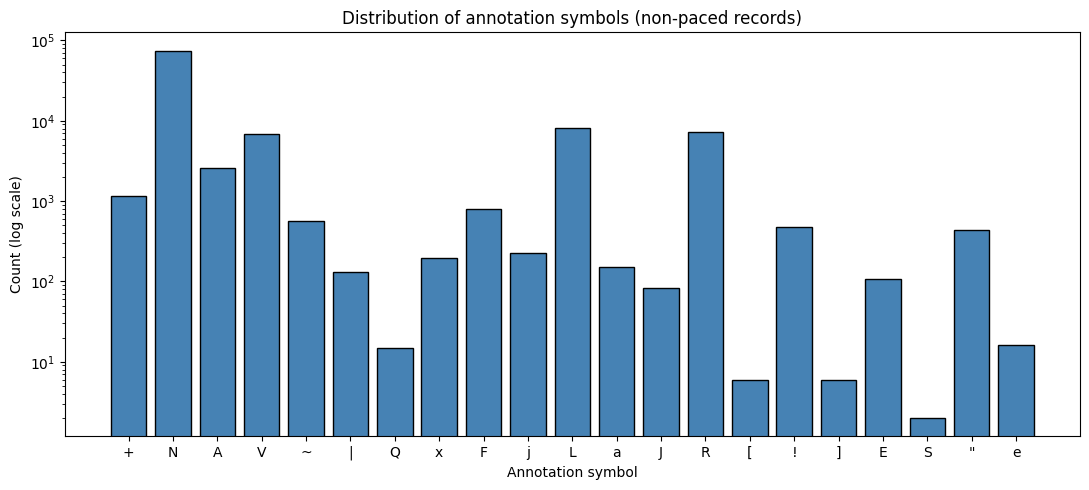

In [4]:
all_symbols = [s for record in records for s in record["anno_symbol"]]
symbol_counts = Counter(all_symbols)

print("Annotation symbols (paced records already excluded):")
for symbol, count in sorted(symbol_counts.items(), key=lambda x: x[1], reverse=True):
    pct = 100 * count / len(all_symbols)
    print(f"  {symbol!r}: {count} ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(list(symbol_counts.keys()), list(symbol_counts.values()),
       color="steelblue", edgecolor="black")
ax.set_yscale("log")
ax.set_title("Distribution of annotation symbols (non-paced records)")
ax.set_xlabel("Annotation symbol")
ax.set_ylabel("Count (log scale)")
plt.tight_layout()
plt.show()

## Visualize Sample Records

The first 10 seconds of a few records, with annotation positions marked in red.

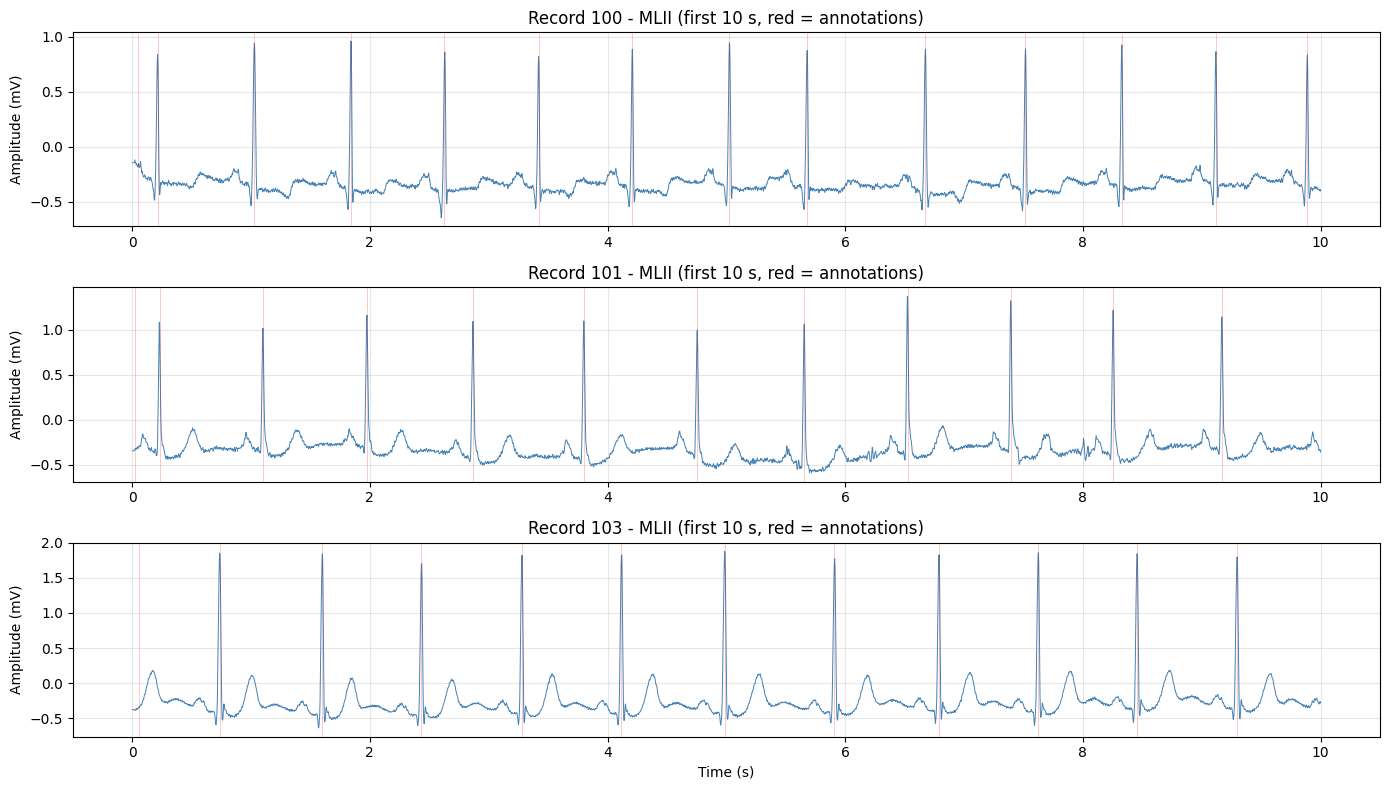

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

for idx in range(3):
    record = records[idx]
    signal = record["signal"][:, 0]
    fs = record["fs"]
    time_axis = np.arange(len(signal)) / fs
    mask = time_axis <= 10

    axes[idx].plot(time_axis[mask], signal[mask], lw=0.7, color="steelblue")
    for sample in record["anno_sample"]:
        t = sample / fs
        if t <= 10:
            axes[idx].axvline(t, color="red", alpha=0.3, lw=0.5)

    axes[idx].set_title(
        f"Record {record['record']} - {record['sig_name'][0]} "
        f"(first 10 s, red = annotations)"
    )
    axes[idx].set_ylabel("Amplitude (mV)")
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## R-Peak Detection vs Annotations

The project segments beats using the **annotated** R-peak positions, which are
reliable expert labels. A simple peak detector (`find_r_peaks`) is also
available for illustration, but the downstream pipeline uses the annotations.

Record 100: 2273 detected R-peaks vs 2274 annotations


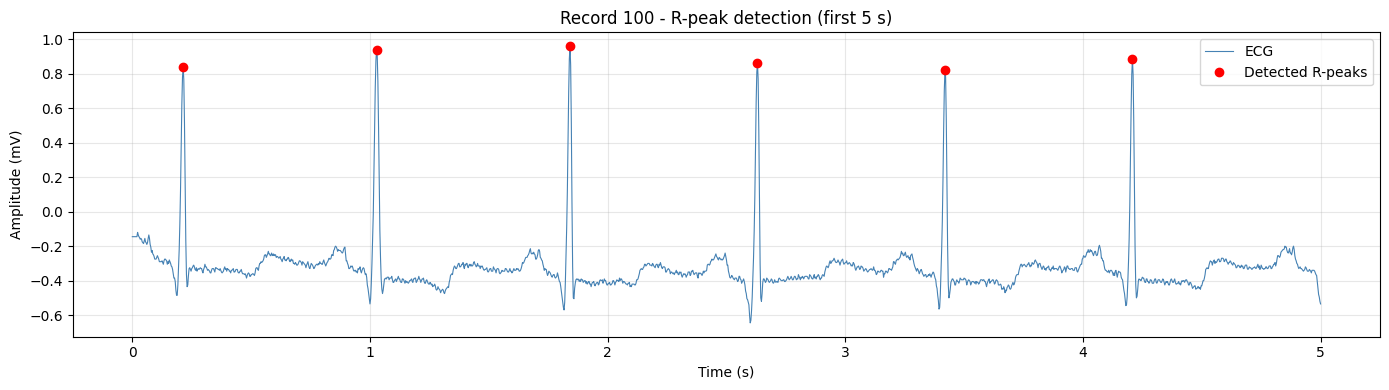

In [6]:
record = records[0]
signal = record["signal"][:, 0]
r_peaks = find_r_peaks(signal, fs=config.FS)

print(f"Record {record['record']}: "
      f"{len(r_peaks)} detected R-peaks vs {len(record['anno_sample'])} annotations")

time_axis = np.arange(len(signal)) / config.FS
mask = time_axis <= 5
peak_t = r_peaks / config.FS
peak_mask = peak_t <= 5

plt.figure(figsize=(14, 4))
plt.plot(time_axis[mask], signal[mask], lw=0.8, color="steelblue", label="ECG")
plt.plot(peak_t[peak_mask], signal[r_peaks][peak_mask], "ro", ms=6,
         label="Detected R-peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record {record['record']} - R-peak detection (first 5 s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Beat Segmentation and Labels

`create_beat_dataset` segments each annotated beat into a window of
`config.BEAT_LEN` samples (90 before and 90 after the R-peak) and assigns a
binary label: normal sinus beats are `0`, every other beat type is `1`.

In [7]:
dataset = create_beat_dataset(records, normalize=True)

print("Beat dataset shape:", dataset.shape)
print(f"Beat length: {config.BEAT_LEN} samples "
      f"({config.BEAT_LEN / config.FS:.3f} s)")

display(dataset[["record", "sample", "symbol", "label", "label_name"]].head())
display(dataset["label_name"].value_counts())
display(dataset["symbol"].value_counts())

Beat dataset shape: (100708, 7)
Beat length: 180 samples (0.500 s)


,record,sample,symbol,label,label_name
0,100,370,N,0,normal
1,100,662,N,0,normal
2,100,946,N,0,normal
3,100,1231,N,0,normal
4,100,1515,N,0,normal


label_name
normal     90102
anomaly    10606
Name: count, dtype: int64

symbol
N    74527
L     8073
R     7257
V     6902
A     2546
F      802
j      229
a      150
E      106
J       83
e       16
Q       15
S        2
Name: count, dtype: int64

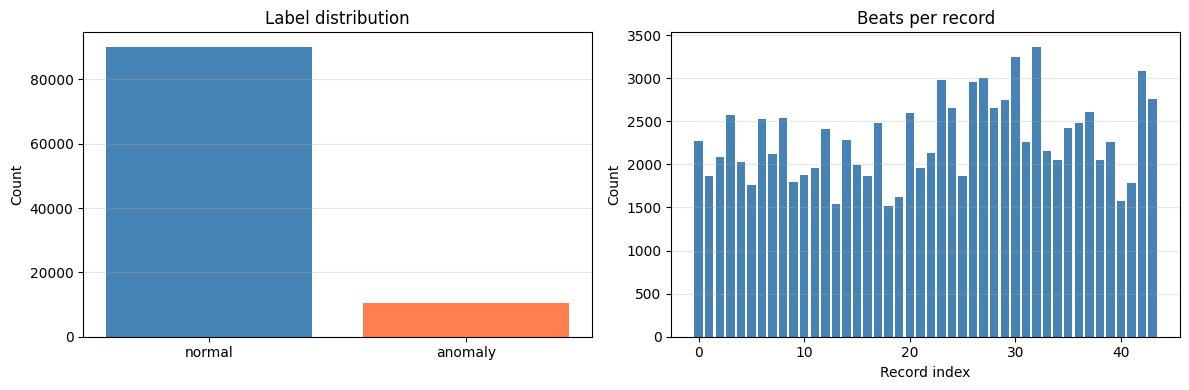

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = dataset["label_name"].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=["steelblue", "coral"])
axes[0].set_title("Label distribution")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3, axis="y")

record_counts = dataset["record"].value_counts().sort_index()
axes[1].bar(range(len(record_counts)), record_counts.values, color="steelblue")
axes[1].set_title("Beats per record")
axes[1].set_xlabel("Record index")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Normal vs Anomaly Beats

A few example beats of each class. Normal beats share a clear, regular
morphology; anomalous beats deviate from it in various ways.

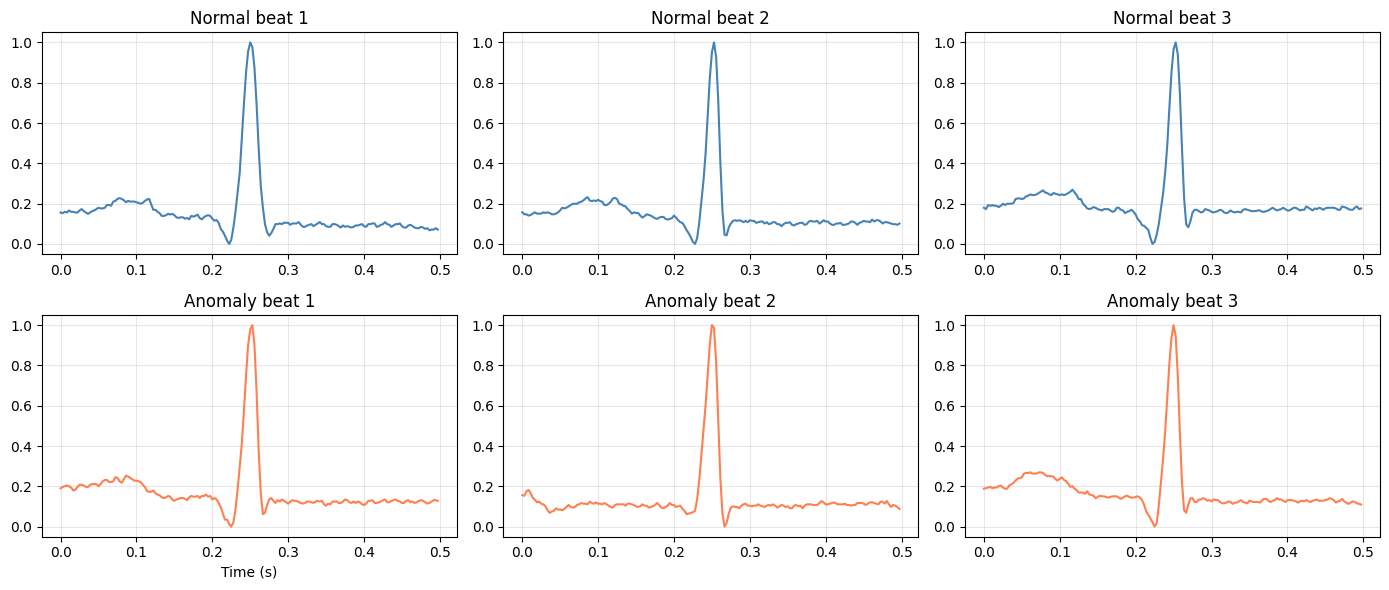

In [9]:
normal_beats = dataset[dataset["label"] == 0]["signal"].values[:3]
anomaly_beats = dataset[dataset["label"] == 1]["signal"].values[:3]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for i, beat in enumerate(normal_beats):
    axes[0, i].plot(np.arange(len(beat)) / config.FS, beat, lw=1.5, color="steelblue")
    axes[0, i].set_title(f"Normal beat {i + 1}")
    axes[0, i].grid(True, alpha=0.3)

for i, beat in enumerate(anomaly_beats):
    axes[1, i].plot(np.arange(len(beat)) / config.FS, beat, lw=1.5, color="coral")
    axes[1, i].set_title(f"Anomaly beat {i + 1}")
    axes[1, i].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Signal Normalization

Each beat window is min-max normalized to the [0, 1] range before modeling. The
plot below illustrates min-max scaling on a raw signal segment (the pipeline
applies the same scaling per beat).

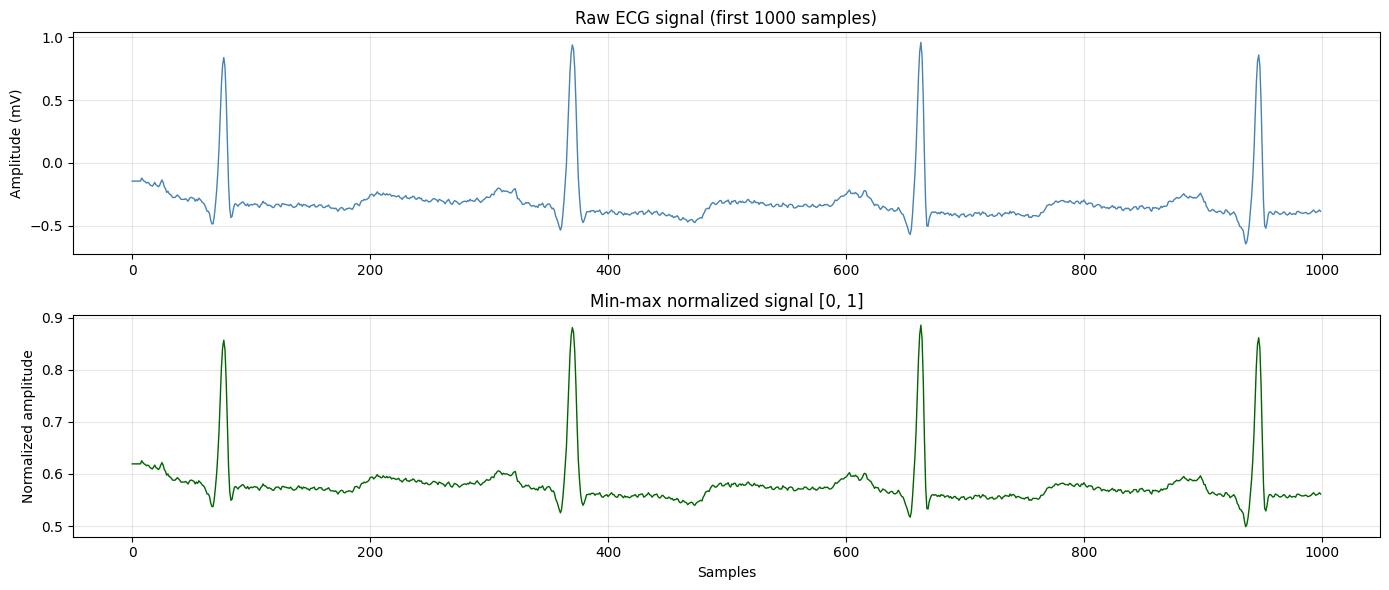

In [10]:
record = records[0]
signal = record["signal"][:, 0]
normalized = normalize_signal(signal)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(signal[:1000], lw=1, color="steelblue")
axes[0].set_title("Raw ECG signal (first 1000 samples)")
axes[0].set_ylabel("Amplitude (mV)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(normalized[:1000], lw=1, color="darkgreen")
axes[1].set_title("Min-max normalized signal [0, 1]")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Normalized amplitude")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

In [11]:
print("=" * 60)
print("MIT-BIH DATA EXPLORATION SUMMARY")
print("=" * 60)
print(f"Records loaded (non-paced): {len(records)}")
print(f"Sampling rate(s): {sorted(set(r['fs'] for r in records))} Hz")
print(f"Total beats: {len(dataset)}")
print(f"  Normal:  {(dataset['label'] == 0).sum()}")
print(f"  Anomaly: {(dataset['label'] == 1).sum()}")
print(f"Beat length: {config.BEAT_LEN} samples "
      f"({config.BEAT_LEN / config.FS:.3f} s)")
print("=" * 60)
print("\nNext steps:")
print("  02 - ARMA baseline")
print("  03 - PCA reconstruction baseline")
print("  04 - LSTM autoencoder")
print("  05 - Variational autoencoder")
print("  06 - Liquid (CfC) autoencoder")

MIT-BIH DATA EXPLORATION SUMMARY
Records loaded (non-paced): 44
Sampling rate(s): [360] Hz
Total beats: 100708
  Normal:  90102
  Anomaly: 10606
Beat length: 180 samples (0.500 s)

Next steps:
  02 - ARMA baseline
  03 - PCA reconstruction baseline
  04 - LSTM autoencoder
  05 - Variational autoencoder
  06 - Liquid (CfC) autoencoder
